# Amazon Product Performance Analysis

## 1. Business Problem

This project analyzes customer ratings and review data for over 1,000 Amazon products. The goal is to understand how discounts, prices, product categories, and review activity relate to customer satisfaction and product performance.

The analysis first explores whether higher discounts are associated with better ratings or more customer reviews. It also identifies which product categories perform best based on average ratings and total review counts.

To make the analysis more meaningful, this project also includes advanced metrics such as weighted average rating, discount effectiveness, value score, and product performance score. These metrics help evaluate product success more comprehensively instead of relying only on simple average ratings or discount levels.

**Research Questions**

1. Does a higher discount percentage lead to higher product ratings?
2. Which product categories have the highest average ratings?
3. Are heavily discounted products more likely to receive customer reviews?
4. What is the relationship between actual price and customer ratings?
5. Which product categories receive the most customer reviews, based on rating count?

## 2. Setup and data Loading:

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# link from the print in smartphones Specification & Prices.py
path = '/Users/xujing/.cache/kagglehub/datasets/karkavelrajaj/amazon-sales-dataset/versions/1'

# ls
print(os.listdir(path))

# find .cvs
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]
print("CSV files:", csv_files)

# ls fisrt csv files 
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)



['amazon.csv']
CSV files: ['amazon.csv']


## 3. Dataset Overview

In [3]:
column_types = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

column_types

,Column Name,Data Type
0,product_id,str
1,product_name,str
2,category,str
3,discounted_price,str
4,actual_price,str
5,discount_percentage,str
6,rating,str
7,rating_count,str
8,about_product,str
9,user_id,str


In [4]:
pd.set_option("display.max_columns", None)
df.head(3)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


## 4. Data Cleaning

In [23]:
df["discounted_price"] = (
    df["discounted_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["discounted_price"] = pd.to_numeric(df["discounted_price"], errors="coerce")

df["actual_price"] = (
    df["actual_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["actual_price"] = pd.to_numeric(df["actual_price"], errors="coerce")

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

df["rating_count"] = (
    df["rating_count"]
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

df["discount_percentage"] = (
    df["discount_percentage"]
    .str.replace("%", "", regex=False)
)

df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")

df["main_category"] = df["category"].str.split("|").str[0]

In [19]:
df[[
    "discounted_price",
    "actual_price",
    "discount_percentage",
    "rating",
    "rating_count",
    "main_category"
]].head()

,discounted_price,actual_price,discount_percentage,rating,rating_count,main_category
0,399.0,1099.0,64,4.2,24269.0,Computers&Accessories
1,199.0,349.0,43,4.0,43994.0,Computers&Accessories
2,199.0,1899.0,90,3.9,7928.0,Computers&Accessories
3,329.0,699.0,53,4.2,94363.0,Computers&Accessories
4,154.0,399.0,61,4.2,16905.0,Computers&Accessories


----

## 5. Exploratory Data Analysis

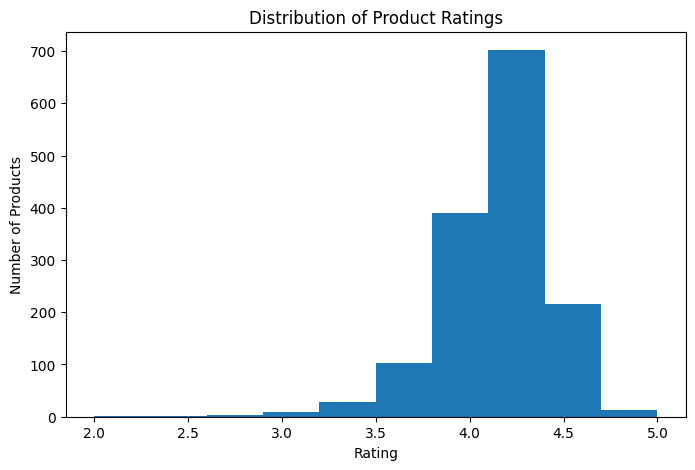

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(df["rating"].dropna(), bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Ratings")
plt.show()

Most product ratings are concentrated between 4.0 and 4.5, which suggests that customer feedback is generally positive.

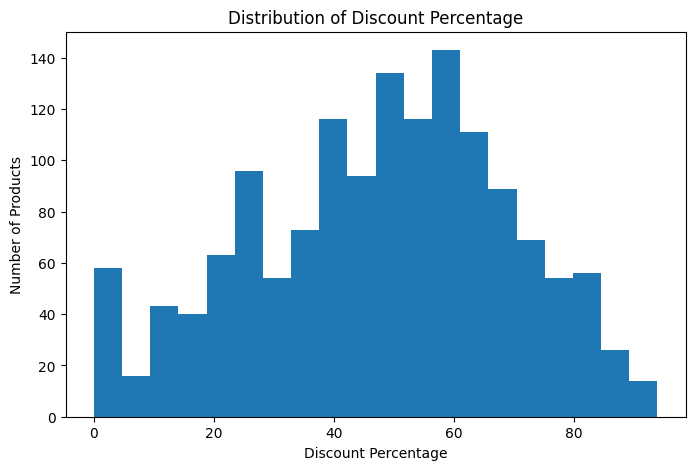

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(df["discount_percentage"].dropna(), bins=20)
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")
plt.title("Distribution of Discount Percentage")
plt.show()

Most products have discount percentages between 40% and 70%, with the highest concentration around 50% to 60%. This suggests that discounting is widely used in this dataset.

## 6. Basic Analysis: Research Questions

### 6.1 Does a higher discount percentage lead to higher product ratings?

In [6]:
rq1_corr = df[["discount_percentage", "rating"]].corr()

rq1_corr

,discount_percentage,rating
discount_percentage,1.000000,-0.155375
rating,-0.155375,1.000000


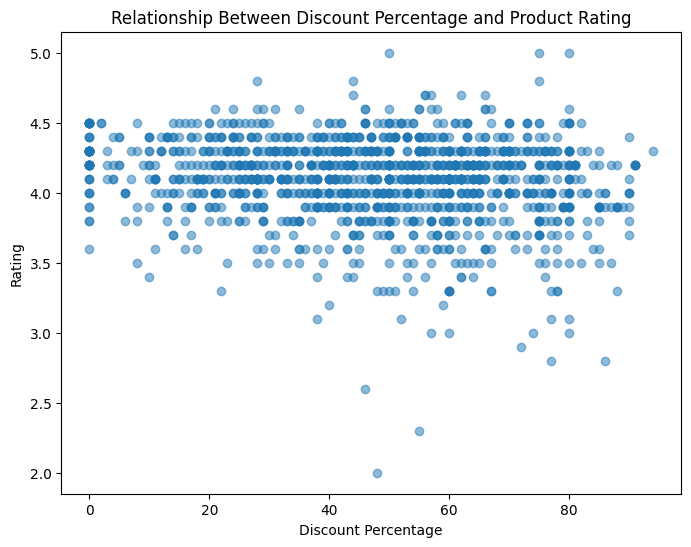

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(df["discount_percentage"], df["rating"], alpha=0.5)
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.title("Relationship Between Discount Percentage and Product Rating")
plt.show()

The scatter plot shows that product ratings are mostly concentrated between 3.8 and 4.5 across different discount levels. There is no clear upward trend, suggesting that higher discounts do not necessarily lead to higher ratings.

----

### 6.2 Which product categories have the highest average ratings?

In [8]:
rq2_table = (
    df.groupby("main_category")["rating"]
    .mean()
    .reset_index()
    .rename(columns={"rating": "average_rating"})
    .sort_values(by="average_rating", ascending=False)
)

rq2_table.head(10)

,main_category,average_rating
7,OfficeProducts,4.309677
8,Toys&Games,4.300000
5,HomeImprovement,4.250000
1,Computers&Accessories,4.154967
2,Electronics,4.081749
4,Home&Kitchen,4.040716
3,Health&PersonalCare,4.000000
6,MusicalInstruments,3.900000
0,Car&Motorbike,3.800000


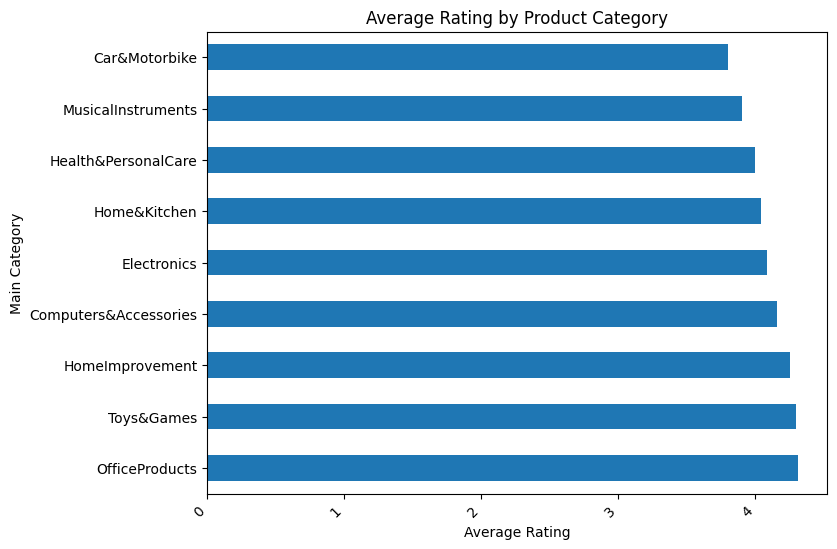

In [9]:
rq2_plot = (
    df.groupby("main_category")["rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
rq2_plot.plot(kind="barh")
plt.xlabel("Average Rating")
plt.ylabel("Main Category")
plt.title("Average Rating by Product Category")
plt.xticks(rotation=45, ha="right")
plt.show()

OfficeProducts, Toys&Games, and HomeImprovement have the highest average ratings, while Car&Motorbike has the lowest average rating.

----

### 6.3 Are heavily discounted products more likely to receive customer reviews?

In [10]:
df["discount_group"] = pd.cut(
    df["discount_percentage"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20%", "21-40%", "41-60%", "61-80%", "81-100%"]
)

rq3_table = (
    df.groupby("discount_group")["rating_count"]
    .mean()
    .reset_index()
    .rename(columns={"rating_count": "average_rating_count"})
)

rq3_table

,discount_group,average_rating_count
0,0-20%,16406.015267
1,21-40%,20265.585799
2,41-60%,15644.307087
3,61-80%,23295.433862
4,81-100%,9587.762712


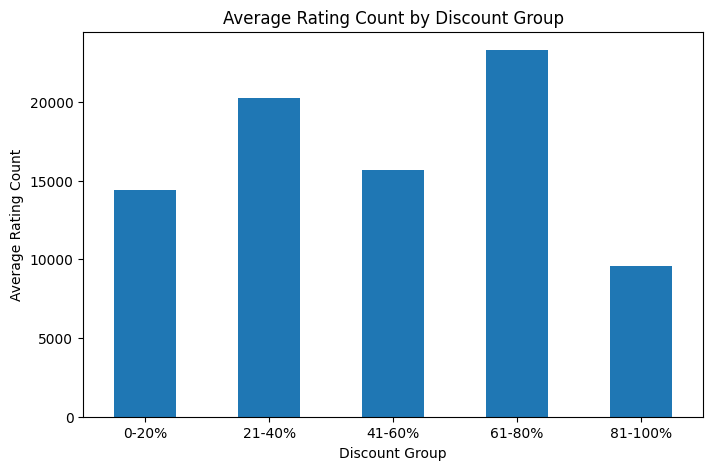

In [11]:
df["discount_group"] = pd.cut(
    df["discount_percentage"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20%", "21-40%", "41-60%", "61-80%", "81-100%"],
    include_lowest=True
)

rq3_plot = (
    df.groupby("discount_group", observed=False)["rating_count"]
    .mean()
)

plt.figure(figsize=(8, 5))
rq3_plot.plot(kind="bar")
plt.xlabel("Discount Group")
plt.ylabel("Average Rating Count")
plt.title("Average Rating Count by Discount Group")
plt.xticks(rotation=0)
plt.show()

Products with 61%–80% discounts receive the highest average number of reviews. However, the 81%–100% discount group receives fewer reviews, which suggests that very high discounts do not always lead to more customer reviews.

----

### 6.4 What is the relationship between actual price and customer ratings?

In [12]:
rq4_corr = df[["actual_price", "rating"]].corr()

rq4_corr

,actual_price,rating
actual_price,1.000000,0.121642
rating,0.121642,1.000000


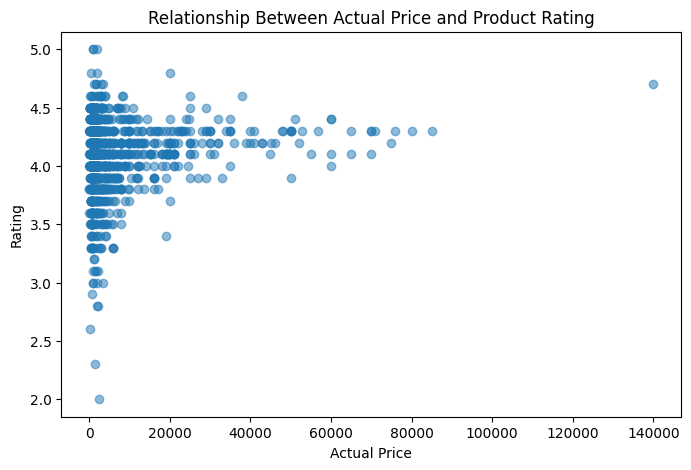

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df["actual_price"], df["rating"], alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Rating")
plt.title("Relationship Between Actual Price and Product Rating")
plt.show()

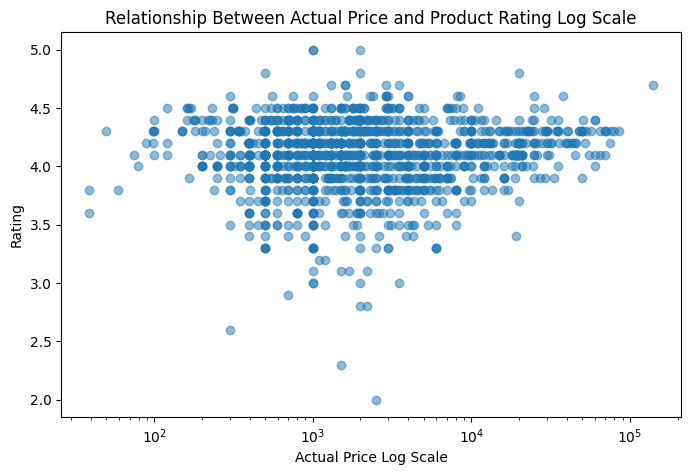

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["actual_price"], df["rating"], alpha=0.5)
plt.xscale("log")
plt.xlabel("Actual Price Log Scale")
plt.ylabel("Rating")
plt.title("Relationship Between Actual Price and Product Rating Log Scale")
plt.show()

Actual price has a weak positive relationship with product rating. Higher-priced products may have slightly higher ratings, but the relationship is not strong.

### 6.5 Which product categories receive the most customer reviews, based on rating count?

In [15]:
rq5_table = (
    df.groupby("main_category")["rating_count"]
    .sum()
    .reset_index()
    .rename(columns={"rating_count": "total_rating_count"})
    .sort_values(by="total_rating_count", ascending=False)
)

rq5_table.head(10)

,main_category,total_rating_count
2,Electronics,15778848.0
1,Computers&Accessories,7728689.0
4,Home&Kitchen,2991069.0
7,OfficeProducts,149675.0
6,MusicalInstruments,88882.0
8,Toys&Games,15867.0
5,HomeImprovement,8566.0
3,Health&PersonalCare,3663.0
0,Car&Motorbike,1118.0


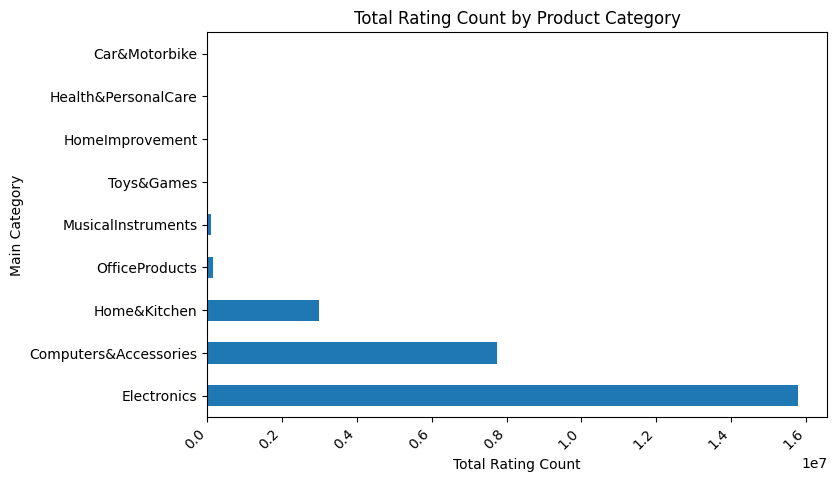

In [16]:
rq5_plot = (
    df.groupby("main_category")["rating_count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
rq5_plot.plot(kind="barh")
plt.xlabel("Total Rating Count")
plt.ylabel("Main Category")
plt.title("Total Rating Count by Product Category")
plt.xticks(rotation=45, ha="right")
plt.show()

Electronics receives the highest total number of customer reviews by far.

## 7. Summary of Visualizations

1. The visualizations show that discounts are widely used in this Amazon product dataset, but higher discounts do not clearly lead to better customer ratings. Most products have discounts between 40% and 70%, especially around 50% to 60%, which suggests that discounting is a common pricing strategy.

2. Product ratings are generally high. Most products are rated between 4.0 and 4.5, meaning that customer feedback is mostly positive. There are very few products with very low ratings.

3. The scatter plot between discount percentage and rating shows no clear upward trend. This means that offering a higher discount does not necessarily improve product ratings. This result is also supported by the weak negative correlation between discount percentage and rating.

4. For product categories, OfficeProducts, Toys&Games, and HomeImprovement have the highest average ratings. This suggests that customers are more satisfied with products in these categories. However, some categories may have fewer products, so the average rating should be interpreted carefully.

5. The discount group chart shows that products with 61%–80% discounts receive the highest average number of reviews. However, the 81%–100% discount group receives fewer reviews, so very large discounts do not always lead to more customer reviews.

6. The scatter plot between actual price and rating shows only a weak positive relationship. Higher-priced products may have slightly higher ratings, but the relationship is not strong. Most ratings still stay around 4.0 to 4.5 across different price levels.

7. Finally, the total review count by category shows that Electronics receives the most customer reviews by far, followed by Computers&Accessories and Home&Kitchen. This suggests that electronics-related products have the highest customer engagement in this dataset.

----


## 8. Advanced Analysis: Feature Engineering and Product Performance

After answering the main research questions, I created additional metrics to evaluate product performance in a deeper way. These metrics consider not only ratings, but also review volume, discount efficiency, price value, and overall product performance.

This section includes:

1. Weighted Average Rating by Category  
2. Discount Effectiveness  
3. Value Score  
4. Product Performance Score  
5. Rating Prediction Model  
6. Feature Importance

### 8.1 Weighted Average Rating by Category

A simple average rating treats every product equally. However, a product with only a few reviews should not have the same influence as a product with thousands of reviews.

To make category comparison more reliable, I calculated a weighted average rating. Products with more reviews receive higher weight in the calculation.

This helps identify which product categories maintain strong customer satisfaction after considering review volume.

In [26]:
weighted_rating_table = (
    df.groupby("main_category")
    .apply(lambda x: (x["rating"] * x["rating_count"]).sum() / x["rating_count"].sum())
    .reset_index(name="weighted_average_rating")
    .sort_values(by="weighted_average_rating", ascending=False)
)

weighted_rating_table

,main_category,weighted_average_rating
5,HomeImprovement,4.349346
7,OfficeProducts,4.327161
8,Toys&Games,4.300000
1,Computers&Accessories,4.226189
2,Electronics,4.149651
4,Home&Kitchen,4.090941
3,Health&PersonalCare,4.000000
6,MusicalInstruments,3.954506
0,Car&Motorbike,3.800000


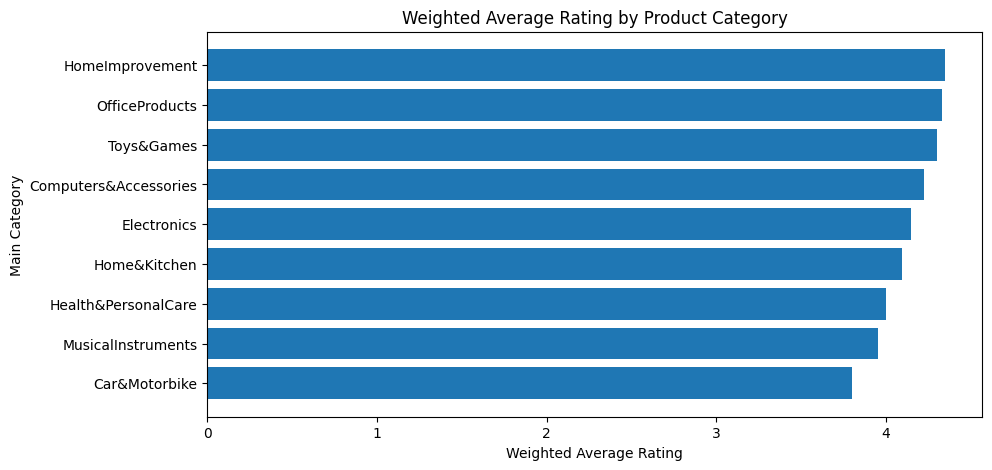

In [27]:
weighted_rating_plot = weighted_rating_table.sort_values(
    by="weighted_average_rating",
    ascending=True
)

plt.figure(figsize=(10, 5))
plt.barh(
    weighted_rating_plot["main_category"],
    weighted_rating_plot["weighted_average_rating"]
)

plt.xlabel("Weighted Average Rating")
plt.ylabel("Main Category")
plt.title("Weighted Average Rating by Product Category")
plt.show()

The weighted average rating gives more importance to products with more customer reviews. This makes the category comparison more reliable than using simple average rating only.

Categories with higher weighted average ratings show stronger and more consistent customer satisfaction because their ratings are supported by larger review volumes.

### 8.2 Discount Effectiveness

A high discount does not always mean strong product performance. To measure how efficiently discounts generate customer engagement, I created a new metric called discount effectiveness.

The formula is:

Discount Effectiveness = Rating Count / (Discount Percentage + 1)

I added 1 to the discount percentage to avoid division by zero.

This metric shows how many customer ratings a product receives per unit of discount. A higher value means the product receives more customer engagement without relying too heavily on discounts.### 2. Discount Effectiveness

In [28]:
df["discount_effectiveness"] = df["rating_count"] / (df["discount_percentage"] + 1)

discount_effectiveness_table = (
    df.groupby("main_category")["discount_effectiveness"]
    .mean()
    .reset_index()
    .sort_values(by="discount_effectiveness", ascending=False)
)

discount_effectiveness_table

,main_category,discount_effectiveness
8,Toys&Games,15867.000000
7,OfficeProducts,1925.458971
2,Electronics,1090.836354
6,MusicalInstruments,869.153005
4,Home&Kitchen,554.010415
1,Computers&Accessories,532.746136
5,HomeImprovement,72.970339
3,Health&PersonalCare,67.833333
0,Car&Motorbike,26.000000


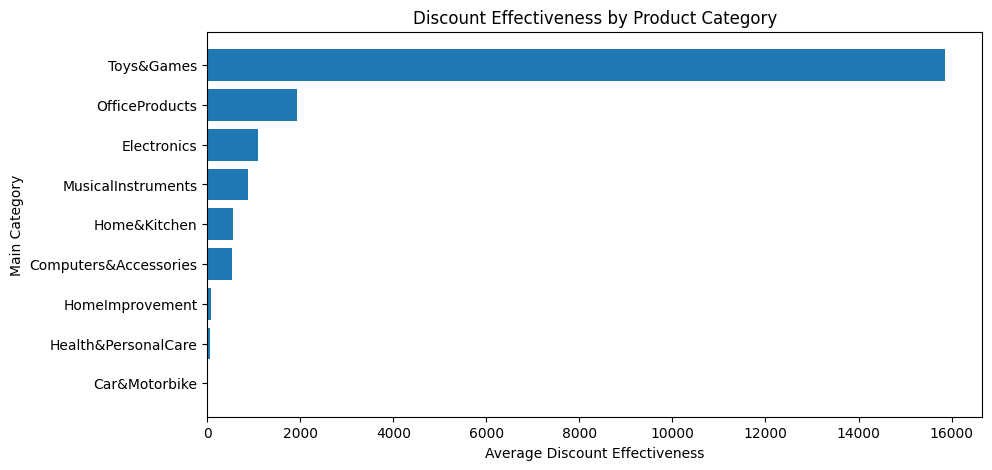

In [29]:
discount_effectiveness_plot = discount_effectiveness_table.sort_values(
    by="discount_effectiveness",
    ascending=True
)

plt.figure(figsize=(10, 5))
plt.barh(
    discount_effectiveness_plot["main_category"],
    discount_effectiveness_plot["discount_effectiveness"]
)

plt.xlabel("Average Discount Effectiveness")
plt.ylabel("Main Category")
plt.title("Discount Effectiveness by Product Category")
plt.show()

Discount effectiveness measures how much customer engagement is generated per unit of discount. A higher score means that a category receives more reviews relative to its discount level.

This helps identify categories where discounts are more efficient. If a category has high discount effectiveness, sellers may not need very large discounts to attract customer engagement.

### 8.3 Value Score

To evaluate product value, I created a value score based on rating and discounted price.

Since product prices vary widely, I used the logarithm of discounted price to reduce the effect of extremely expensive products.

The formula is:

Value Score = Rating / log(1 + Discounted Price)

A higher value score means the product provides better customer-rated value relative to its price.

In [30]:
df["value_score"] = df["rating"] / np.log1p(df["discounted_price"])

value_score_table = (
    df.groupby("main_category")["value_score"]
    .mean()
    .reset_index()
    .sort_values(by="value_score", ascending=False)
)

value_score_table

,main_category,value_score
8,Toys&Games,0.857038
7,OfficeProducts,0.821826
5,HomeImprovement,0.737837
1,Computers&Accessories,0.701023
6,MusicalInstruments,0.607107
3,Health&PersonalCare,0.588028
2,Electronics,0.578072
4,Home&Kitchen,0.577965
0,Car&Motorbike,0.489823


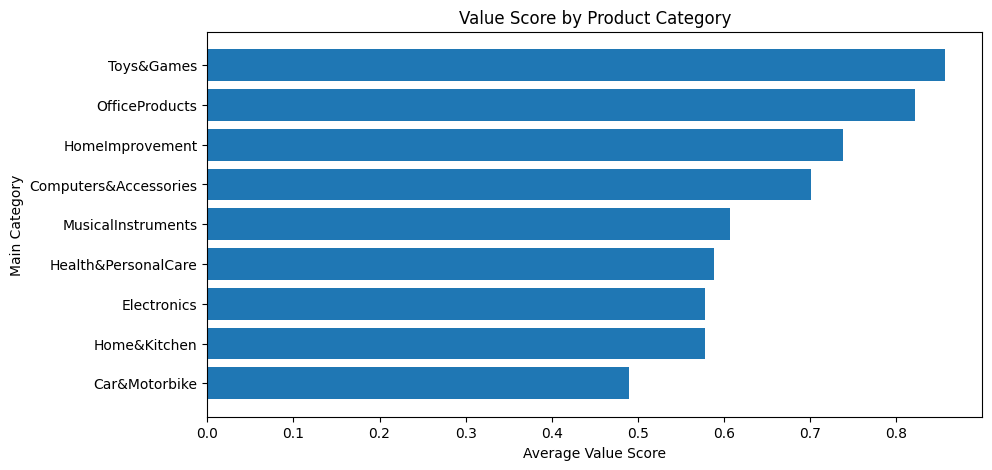

In [31]:
value_score_plot = value_score_table.sort_values(
    by="value_score",
    ascending=True
)

plt.figure(figsize=(10, 5))
plt.barh(
    value_score_plot["main_category"],
    value_score_plot["value_score"]
)

plt.xlabel("Average Value Score")
plt.ylabel("Main Category")
plt.title("Value Score by Product Category")
plt.show()

The value score compares product rating with discounted price. It helps identify categories that provide stronger customer-rated value for money.

Categories with higher value scores may offer better perceived value because they receive good ratings while maintaining relatively lower prices.

### 8.4 Product Performance Score

To identify the best overall products, I created a product performance score.

The score combines three factors:

- Product rating
- Rating count
- Discount percentage

The weights are:

- 50% rating
- 40% rating count
- 10% discount percentage

Rating is weighted the most because customer satisfaction is the main indicator of product quality. Rating count is also important because it reflects customer engagement and popularity. Discount percentage receives a smaller weight because higher discounts do not always mean better product performance.

In [32]:
from sklearn.preprocessing import MinMaxScaler

score_df = df[[
    "product_name",
    "main_category",
    "rating",
    "rating_count",
    "discount_percentage"
]].dropna().copy()

scaler = MinMaxScaler()

score_df[[
    "rating_scaled",
    "rating_count_scaled",
    "discount_scaled"
]] = scaler.fit_transform(
    score_df[["rating", "rating_count", "discount_percentage"]]
)

score_df["performance_score"] = (
    0.5 * score_df["rating_scaled"] +
    0.4 * score_df["rating_count_scaled"] +
    0.1 * score_df["discount_scaled"]
)

top_products = (
    score_df.sort_values(by="performance_score", ascending=False)
    .head(10)
)

top_products[[
    "product_name",
    "main_category",
    "rating",
    "rating_count",
    "discount_percentage",
    "performance_score"
]]

,product_name,main_category,rating,rating_count,discount_percentage,performance_score
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",Electronics,4.4,426973.0,78,0.882979
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,Electronics,4.4,426973.0,69,0.873404
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,Electronics,4.4,426972.0,69,0.873403
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",Electronics,4.4,426973.0,35,0.837234
352,boAt Bassheads 100 in Ear Wired Earphones with...,Electronics,4.1,363713.0,65,0.759885
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,Electronics,4.1,363711.0,63,0.757755
400,boAt Bassheads 100 in Ear Wired Earphones with...,Electronics,4.1,363713.0,62,0.756693
588,SanDisk Cruzer Blade 32GB USB Flash Drive,Computers&Accessories,4.3,253105.0,56,0.680023
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",Electronics,4.1,313836.0,24,0.669542
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",Electronics,4.1,313836.0,23,0.668478


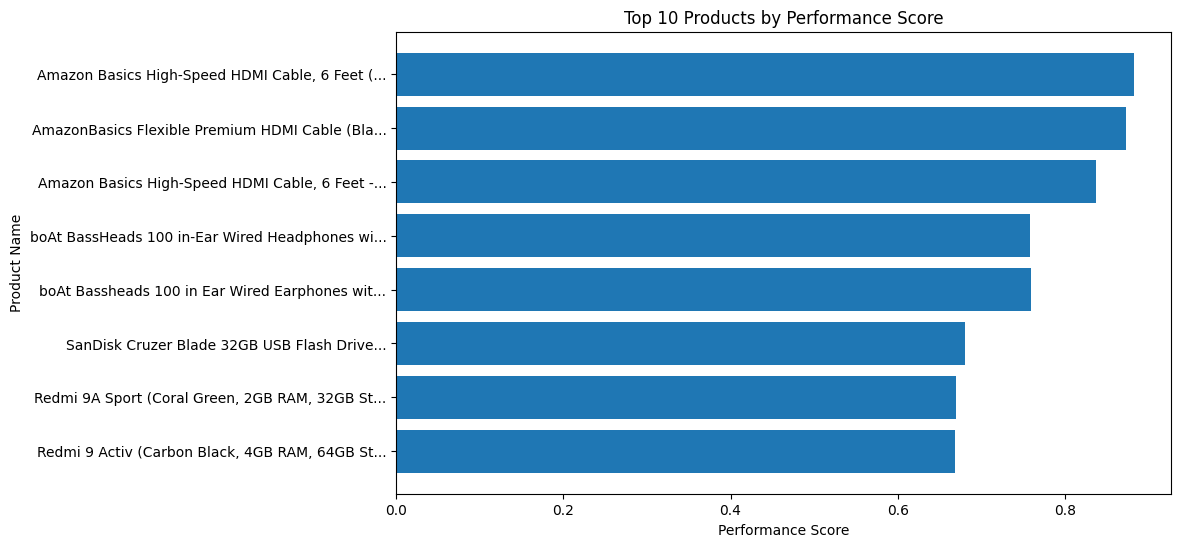

In [35]:
top_products_plot = top_products.copy()

top_products_plot["short_name"] = (
    top_products_plot["product_name"].str[:45] + "..."
)

top_products_plot = top_products_plot.sort_values(
    by="performance_score",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_products_plot["short_name"],
    top_products_plot["performance_score"]
)

plt.xlabel("Performance Score")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Performance Score")
plt.show()

The performance score ranks products based on customer satisfaction, popularity, and discount level. This provides a more balanced way to identify strong products instead of only looking at rating or review count separately.

The top-ranked products are those that have strong ratings, high customer engagement, and competitive discount levels.

### 8.5 Rating Prediction Model

To make the project more advanced, I built a machine learning model to predict product ratings.

The goal is to understand whether product price, discount, review count, and category can explain product ratings.

The target variable is:

rating

The input features are:

- actual_price
- discounted_price
- discount_percentage
- rating_count
- main_category

Since main_category is categorical, I converted it into dummy variables before training the model.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_df = df[[
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating_count",
    "main_category",
    "rating"
]].dropna().copy()

X = model_df.drop(columns="rating")
y = model_df["rating"]

X = pd.get_dummies(X, columns=["main_category"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 0.17335494880546087
R2 Score: 0.20955117137771373


The Mean Absolute Error shows the average prediction error in rating points. A lower MAE means the model predicts ratings more accurately.

The R2 score shows how much of the rating variation is explained by the model. If the R2 score is low, it means price, discount, rating count, and category alone are not enough to fully explain product ratings.

This is reasonable because product ratings may also depend on factors not included in the dataset, such as product quality, brand reputation, delivery experience, and customer expectations.

### 8.6 Feature Importance

After training the Random Forest model, I checked feature importance to understand which variables contribute the most to rating prediction.

This helps identify which product factors are most useful for explaining customer ratings.

In [38]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(10)

,feature,importance
3,rating_count,0.357377
1,discounted_price,0.193388
2,discount_percentage,0.189624
0,actual_price,0.174846
4,main_category_Computers&Accessories,0.036347
7,main_category_Home&Kitchen,0.022729
5,main_category_Electronics,0.017423
10,main_category_OfficeProducts,0.006768
8,main_category_HomeImprovement,0.000709
9,main_category_MusicalInstruments,0.000643


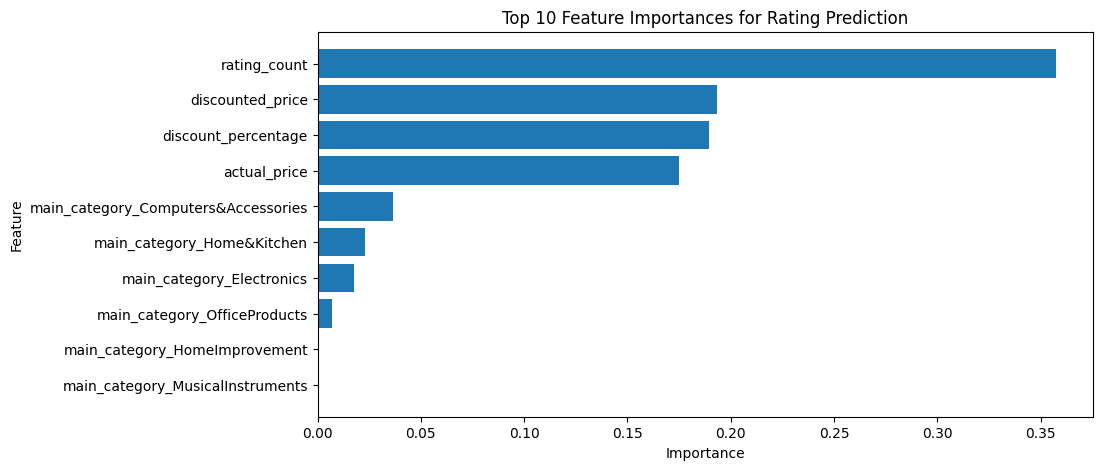

In [39]:
top_features = feature_importance.head(10).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 5))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances for Rating Prediction")
plt.show()

The feature importance chart shows which variables the model used most when predicting product ratings.

If rating count or price-related variables appear near the top, it means they are more useful for explaining rating differences. However, feature importance does not prove causation. It only shows which features are more informative for the prediction model.

### 8.7 Advanced Analysis Summary

The advanced analysis provides deeper insights into product performance. Weighted average rating gives a more reliable comparison of customer satisfaction across categories by considering review volume. Discount effectiveness shows how efficiently discounts generate customer engagement. Value score helps identify categories that provide better customer-rated value for money.

The product performance score combines rating, rating count, and discount percentage to rank the best overall products. The machine learning model further explores whether price, discount, review count, and category can explain product ratings.

Overall, this section shows that product success should not be evaluated by discount level alone. Customer satisfaction, review volume, price value, and category performance should be considered together.